# Dependencias

In [ ]:
!pip install albumentations==1.4.7 opencv-python==4.10.0.84

# Librerias

In [ ]:
import os, re, json, shutil, random, pathlib, math
from collections import defaultdict
from google.colab import drive
import matplotlib.pyplot as plt
import os, json, pathlib
import numpy as np
import cv2, albumentations as A
import tensorflow as tf
from tensorflow.keras import layers as L, Model
import os, re, glob, zipfile, tensorflow as tf
from tensorflow.keras.callbacks import (ModelCheckpoint, EarlyStopping,
                                        ReduceLROnPlateau, CSVLogger, TensorBoard)
from tensorflow.keras.applications import ResNet50, InceptionResNetV2
import json, os



# Carga Dataset

In [ ]:
# Montar Drive
drive.mount('/content/drive')

# Rutas
DATASET_ROOT = '/content/drive/MyDrive/Colab/Geotermia/DubaiDataset'
OUT_DIR      = '/content/drive/MyDrive/Colab/Geotermia/DubaiDataset'
os.makedirs(OUT_DIR, exist_ok=True)

# Subcarpetas estándar dentro de cada tile
IMG_SUB  = 'images'
MASK_SUB = 'masks'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Separación del dataset

In [ ]:
# Parámetros del Split
N_TRAIN = 58
N_VAL   = 14
N_TEST  = 0

In [ ]:
STRATIFY_BY_TILE = True

# Reproducibilidad
SEED = 2025
random.seed(SEED)

# Extensiones aceptadas
IMG_EXTS  = {'.png', '.jpg', '.jpeg', '.tif', '.tiff'}
MASK_EXTS = {'.png', '.jpg', '.jpeg', '.tif', '.tiff'}

COPY_FILES = False

# Caracterización del Dataset

In [ ]:
# Utilidades
def list_files(root, exts):
    out = []
    for r, _, fns in os.walk(root):
        for fn in fns:
            if pathlib.Path(fn).suffix.lower() in exts:
                out.append(os.path.join(r, fn))
    return sorted(out)

def stem(p):
    return pathlib.Path(p).stem

def write_list(fname, pairs_subset):
    with open(fname, 'w') as f:
        for tile, s, ip, mp in pairs_subset:
            f.write(f"{ip}\t{mp}\n")

def round_split(n_total, n_train, n_val, n_test):
    n_train = max(0, min(n_train, n_total))
    n_val   = max(0, min(n_val,   n_total - n_train))
    n_test  = max(0, min(n_test,  n_total - n_train - n_val))
    return n_train, n_val, n_test

# Clases en formato JSON



*   Building
*   Land
*   Road
*   Vegetation
*   Water
*   Miscellaneous







In [ ]:
# Leer classes.json
classes_json_path = os.path.join(DATASET_ROOT, 'classes.json')
classes = []
if os.path.isfile(classes_json_path):
    with open(classes_json_path, 'r') as f:
        data = json.load(f)
    classes = data.get('classes', [])
    with open(os.path.join(OUT_DIR, 'classes.txt'), 'w') as f:
        for idx, c in enumerate(classes):
            title = c.get('title', f'class_{idx}')
            color = c.get('color', '')
            f.write(f"{idx}\t{title}\t{color}\n")
    print(f"classes.json leído. {len(classes)} clases. Resumen -> {os.path.join(OUT_DIR,'classes.txt')}")
else:
    print("No se encontró classes.json en DATASET_ROOT.")

[OK] classes.json leído. 6 clases. Resumen -> /content/drive/MyDrive/Colab/Geotermia/DubaiDataset/classes.txt


# Carpetas

# 8 carpetas nombradas como tile cada una con 9 imágenes y sus correspondientes máscaras-Ground Truth. La base de datos está compuesta por 72 imágenes

In [ ]:
#  Detectar tiles y emparejar imagen máscara por tile

tile_dirs = [d for d in sorted(os.listdir(DATASET_ROOT)) if os.path.isdir(os.path.join(DATASET_ROOT, d)) and d.lower().startswith('tile')]
if not tile_dirs:
    raise RuntimeError("No se encontraron subcarpetas 'Tile *'")

all_pairs = []
per_tile_counts = {}

for tile in tile_dirs:
    tile_path = os.path.join(DATASET_ROOT, tile)
    img_dir   = os.path.join(tile_path, IMG_SUB)
    mask_dir  = os.path.join(tile_path, MASK_SUB)

    if not os.path.isdir(img_dir) or not os.path.isdir(mask_dir):
        print(f"[ADVERTENCIA] {tile}: falta {IMG_SUB} o {MASK_SUB}.")
        continue

    imgs  = list_files(img_dir,  IMG_EXTS)
    masks = list_files(mask_dir, MASK_EXTS)

    imgs_by_stem  = {stem(p): p for p in imgs}
    masks_by_stem = {stem(p): p for p in masks}
    common = sorted(set(imgs_by_stem.keys()) & set(masks_by_stem.keys()))

    tile_pairs = [(tile, s, imgs_by_stem[s], masks_by_stem[s]) for s in common]
    all_pairs.extend(tile_pairs)
    per_tile_counts[tile] = len(tile_pairs)
    print(f"[{tile}] pares emparejados: {len(tile_pairs)}")

if not all_pairs:
    raise RuntimeError("No se encontraron pares imagen-máscara en ningún tile.")

TOTAL = len(all_pairs)
print(f"\nTOTAL pares en todos los tiles: {TOTAL}")
print("Detalle por tile:", per_tile_counts)

[Tile 1] pares emparejados: 9
[Tile 2] pares emparejados: 9
[Tile 3] pares emparejados: 9
[Tile 4] pares emparejados: 9
[Tile 5] pares emparejados: 9
[Tile 6] pares emparejados: 9
[Tile 7] pares emparejados: 9
[Tile 8] pares emparejados: 9

TOTAL pares en todos los tiles: 72
Detalle por tile: {'Tile 1': 9, 'Tile 2': 9, 'Tile 3': 9, 'Tile 4': 9, 'Tile 5': 9, 'Tile 6': 9, 'Tile 7': 9, 'Tile 8': 9}


# Preparación del dataset

Train, val, test

In [ ]:

pairs_by_tile = defaultdict(list)
for rec in all_pairs:
    pairs_by_tile[rec[0]].append(rec)

for tile, arr in pairs_by_tile.items():
    random.shuffle(arr)

train_pairs, val_pairs, test_pairs = [], [], []

if STRATIFY_BY_TILE:

    def allocate(total_target):
        out = []

        remaining = total_target
        per_tile_quota = {}
        total_pairs = {t: len(arr) for t, arr in pairs_by_tile.items()}
        grand_total = sum(total_pairs.values())
        for t, cnt in total_pairs.items():
            q = int(round(total_target * (cnt / grand_total)))
            per_tile_quota[t] = q

        diff = total_target - sum(per_tile_quota.values())

        tiles_sorted = sorted(per_tile_quota.keys())
        i = 0
        while diff != 0 and tiles_sorted:
            t = tiles_sorted[i % len(tiles_sorted)]

            can_add = (diff > 0) and (per_tile_quota[t] < total_pairs[t])
            can_sub = (diff < 0) and (per_tile_quota[t] > 0)
            if can_add:
                per_tile_quota[t] += 1
                diff -= 1
            elif can_sub:
                per_tile_quota[t] -= 1
                diff += 1
            i += 1
            if i > 10000:
                break

        for t in sorted(pairs_by_tile.keys()):
            take = min(per_tile_quota[t], len(pairs_by_tile[t]))
            out.extend(pairs_by_tile[t][:take])
            pairs_by_tile[t] = pairs_by_tile[t][take:]
        return out

    train_pairs = allocate(N_TRAIN)
    val_pairs   = allocate(N_VAL)
    test_pairs  = allocate(N_TEST) if N_TEST > 0 else []
else:

    global_list = []
    for arr in pairs_by_tile.values():
        global_list.extend(arr)
    random.shuffle(global_list)
    train_pairs = global_list[:N_TRAIN]
    val_pairs   = global_list[N_TRAIN:N_TRAIN+N_VAL]
    test_pairs  = global_list[N_TRAIN+N_VAL:N_TRAIN+N_VAL+N_TEST] if N_TEST > 0 else []

In [ ]:
if COPY_FILES:
    def copy_subset(name, subset):
        img_out  = os.path.join(OUT_DIR, 'splits', name, 'images')
        mask_out = os.path.join(OUT_DIR, 'splits', name, 'masks')
        os.makedirs(img_out,  exist_ok=True)
        os.makedirs(mask_out, exist_ok=True)
        for tile, s, ip, mp in subset:
            shutil.copy2(ip,  os.path.join(img_out,  f"{tile}__{os.path.basename(ip)}"))
            shutil.copy2(mp,  os.path.join(mask_out, f"{tile}__{os.path.basename(mp)}"))
        print(f" {name}: {len(subset)}")
    copy_subset('train', train_pairs)
    copy_subset('val',   val_pairs)
    if N_TEST > 0:
        copy_subset('test',  test_pairs)

Imágen satelital -máscaras

In [ ]:
# Muestra rápida
print("\nEjemplos de train.txt:")
with open(os.path.join(OUT_DIR, 'train.txt')) as f:
    for _ in range(min(3, len(train_pairs))):
        print(f.readline().strip())



Ejemplos de train.txt:
/content/drive/MyDrive/Colab/Geotermia/DubaiDataset/Tile 1/images/image_part_007.jpg	/content/drive/MyDrive/Colab/Geotermia/DubaiDataset/Tile 1/masks/image_part_007.png
/content/drive/MyDrive/Colab/Geotermia/DubaiDataset/Tile 1/images/image_part_003.jpg	/content/drive/MyDrive/Colab/Geotermia/DubaiDataset/Tile 1/masks/image_part_003.png
/content/drive/MyDrive/Colab/Geotermia/DubaiDataset/Tile 1/images/image_part_005.jpg	/content/drive/MyDrive/Colab/Geotermia/DubaiDataset/Tile 1/masks/image_part_005.png


# Rutas de las clases en formato JSON y clases en formato TXT para Train y Val

In [ ]:

# RUTAS
CLASSES_JSON = '/content/drive/MyDrive/Colab/Geotermia/DubaiDataset/classes.json'
TRAIN_TXT    = '/content/drive/MyDrive/Colab/Geotermia/DubaiDataset/train.txt'
VAL_TXT      = '/content/drive/MyDrive/Colab/Geotermia/DubaiDataset/val.txt'


IMG_SIZE     = (256, 256)
IGNORE_INDEX = 255

# Paleta desde classes.json

def load_palette(path):
    data = json.load(open(path))
    pal = []
    for c in data['classes']:
        h = c['color'].lstrip('#')
        pal.append(tuple(int(h[i:i+2],16) for i in (0,2,4)))
    return pal

PALETTE = load_palette(CLASSES_JSON)
NUM_CLASSES = len(PALETTE)
COLOR2ID = {tuple(rgb): i for i, rgb in enumerate(PALETTE)}


COLOR_ALIAS = {
    (110,193,228): (80,227,194),   # #6EC1E4 -> Water #50E3C2
    (226,169,41):  (245,166,35),   # #E2A929 -> Land  #F5A623
    (254,221,58):  (222,89,127),   # #FEDD3A -> Road  #DE597F
    (60,16,152):   (208,2,27),     # #3C1098 -> Building #D0021B
    (132,41,246):  (65,117,5),     # #8429F6 -> Vegetation #417505
    (0,0,0):       (155,155,155),  # #000000 -> Unlabeled #9B9B9B
}

def apply_alias(mask_rgb: np.ndarray) -> np.ndarray:
    m = mask_rgb.copy()
    for src, dst in COLOR_ALIAS.items():
        sel = (m[:,:,0]==src[0]) & (m[:,:,1]==src[1]) & (m[:,:,2]==src[2])
        m[sel] = np.array(dst, dtype=np.uint8)
    return m

def rgb_to_ids(mask_rgb: np.ndarray) -> np.ndarray:
    out = np.full(mask_rgb.shape[:2], IGNORE_INDEX, dtype=np.uint8)
    for rgb, idx in COLOR2ID.items():
        match = (mask_rgb[:,:,0]==rgb[0]) & (mask_rgb[:,:,1]==rgb[1]) & (mask_rgb[:,:,2]==rgb[2])
        out[match] = idx
    return out

def ids_to_onehot(mask_ids: np.ndarray) -> np.ndarray:
    h,w = mask_ids.shape
    onehot = np.zeros((h,w,NUM_CLASSES), dtype=np.float32)

    onehot[np.arange(h)[:,None], np.arange(w)[None,:], mask_ids] = 1.0
    return onehot

# Augmentaciones

def make_transforms(train=True, img_size=IMG_SIZE):
    ops = []
    if train:
        ops += [
            A.HorizontalFlip(p=0.5),
            A.VerticalFlip(p=0.5),
            A.ShiftScaleRotate(shift_limit=0.10, scale_limit=0.15, rotate_limit=30,
                               border_mode=cv2.BORDER_REFLECT_101, p=0.75),
        ]
    if img_size is not None:

        ops.append(A.Resize(img_size[0], img_size[1], interpolation=cv2.INTER_LINEAR))
    return A.Compose(ops)

TFMS_TRAIN = make_transforms(train=True,  img_size=IMG_SIZE)
TFMS_VAL   = make_transforms(train=False, img_size=IMG_SIZE)

def parse_txt(txt_path):
    with open(txt_path,'r') as f:
        return [tuple(line.strip().split('\t')) for line in f if line.strip()]

pairs_train = parse_txt(TRAIN_TXT)
pairs_val   = parse_txt(VAL_TXT)

def _load_and_aug(img_path, mask_path, train=True):

    img  = cv2.imread(img_path.decode('utf-8'), cv2.IMREAD_COLOR)
    img  = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    mrgb = cv2.imread(mask_path.decode('utf-8'), cv2.IMREAD_COLOR)
    mrgb = cv2.cvtColor(mrgb, cv2.COLOR_BGR2RGB)


    mrgb = apply_alias(mrgb)
    mids = rgb_to_ids(mrgb)
    mids[mids == IGNORE_INDEX] = 0


    tfms = TFMS_TRAIN if train else TFMS_VAL
    augmented = tfms(image=img, mask=mids)
    img  = augmented['image'].astype(np.float32) / 255.0
    mids = augmented['mask']


    m1h  = ids_to_onehot(mids)
    return img, m1h

def tf_loader(pairs, train=True, batch_size=8, shuffle=True):
    img_paths  = [p[0] for p in pairs]
    mask_paths = [p[1] for p in pairs]
    ds = tf.data.Dataset.from_tensor_slices((img_paths, mask_paths))
    if shuffle:
        ds = ds.shuffle(len(pairs), reshuffle_each_iteration=True)

    def _pyfunc(img_p, mask_p):
        img, m1h = tf.numpy_function(
            func=_load_and_aug,
            inp=[img_p, mask_p, train],
            Tout=[tf.float32, tf.float32]
        )

        img.set_shape([IMG_SIZE[0], IMG_SIZE[1], 3])
        m1h.set_shape([IMG_SIZE[0], IMG_SIZE[1], NUM_CLASSES])
        return img, m1h

    return ds.map(_pyfunc, num_parallel_calls=tf.data.AUTOTUNE) \
             .batch(batch_size) \
             .prefetch(tf.data.AUTOTUNE)

train_ds = tf_loader(pairs_train, train=True,  batch_size=8, shuffle=True)
val_ds   = tf_loader(pairs_val,   train=False, batch_size=8, shuffle=False)


for xb, yb in train_ds.take(1):
    print("Batch shapes:", xb.shape, yb.shape)
print("Num clases:", NUM_CLASSES)


def audit_unknown(ds, n_batches=2):
    unknown_total = 0
    total = 0
    for xb, yb in ds.take(n_batches):

        s = tf.reduce_sum(yb, axis=-1)  # (B,H,W)
        unknown_total += int(tf.reduce_sum(tf.cast(tf.equal(s, 0.0), tf.int32)))
        total        += int(tf.size(s))
    print(f"Px sin clase (esperado=0): {unknown_total}/{total} = {unknown_total/total:.6f}")

audit_unknown(train_ds)
audit_unknown(val_ds)


Batch shapes: (8, 256, 256, 3) (8, 256, 256, 6)
Num clases: 6
Px sin clase (esperado=0): 0/1048576 = 0.000000
Px sin clase (esperado=0): 0/917504 = 0.000000


# Entrenamiento U-NET

In [ ]:

def conv_block(x, filters, k=3, s=1, p="same", act="relu", bn=True, dr=0.0):
    x = layers.Conv2D(filters, k, s, padding=p, use_bias=not bn)(x)
    if bn: x = layers.BatchNormalization()(x)
    x = layers.Activation(act)(x)
    if dr > 0: x = layers.Dropout(dr)(x)
    x = layers.Conv2D(filters, k, s, padding=p, use_bias=not bn)(x)
    if bn: x = layers.BatchNormalization()(x)
    x = layers.Activation(act)(x)
    return x

def pick_pyramid_feature_maps_safe(backbone, min_size=8, top_k=4):

    feats = []
    seen_hw = set()


    for layer in backbone.layers:
        out_shape = getattr(layer, "output_shape", None)
        if out_shape is None:
            continue

        if isinstance(out_shape, (list, tuple)) and isinstance(out_shape[0], (list, tuple)):
            continue
        if isinstance(out_shape, list):
            out_shape = tuple(out_shape)
        if not (isinstance(out_shape, tuple) and len(out_shape) == 4):
            continue
        _, h, w, c = out_shape
        if h is None or w is None or h < min_size or w < min_size:
            continue
        feats.append((h*w, h, w, layer.output))

    if not feats:
        return []


    feats.sort(key=lambda t: t[0])
    ordered = []
    used = set()
    for _, h, w, out in feats:
        if (h, w) not in used:
            ordered.append(out)
            used.add((h, w))
        if len(ordered) == top_k:
            break


    return ordered

def build_unet_with_encoder(
    input_shape=(256,256,3),
    num_classes=NUM_CLASSES,
    encoder_name="resnet50",
    encoder_weights="imagenet",
    decoder_dropout=0.30,
    freeze_encoder_epochs=0,
    from_logits=True
):
    #  Encoder

    if encoder_name.lower() == "resnet50":
        enc = ResNet50(include_top=False, weights=encoder_weights, input_shape=input_shape)
    elif encoder_name.lower() in ["inceptionresnetv2", "inception-resnet-v2", "inception_resnet_v2"]:
        enc = InceptionResNetV2(include_top=False, weights=encoder_weights, input_shape=input_shape)
    else:
        raise ValueError("Encoder no soportado. Usa 'resnet50' o 'inceptionresnetv2'.")
    if freeze_encoder_epochs and freeze_encoder_epochs > 0:
        for l in enc.layers:
            l.trainable = False


    feats = pick_pyramid_feature_maps_safe(enc, min_size=8, top_k=4)
    if len(feats) < 2:
        raise RuntimeError("No se pudieron extraer suficientes feature maps del encoder.")

    deep, *skips = feats

    inputs = enc.input
    x = deep

    # Decoder

    dec_channels = [256, 128, 64, 32][:len(skips)]
    for ch, skip in zip(dec_channels, skips):
        x = layers.Conv2DTranspose(ch, 2, strides=2, padding="same")(x)
        x = layers.Concatenate()([x, skip])
        x = conv_block(x, ch, dr=decoder_dropout)

    # Cabeza de segmentación

    x = layers.Conv2D(32, 3, padding="same")(x)
    x = layers.Activation("relu")(x)

    if from_logits:
        outputs = layers.Conv2D(num_classes, 1, padding="same", activation=None, name="logits")(x)
    else:
        outputs = layers.Conv2D(num_classes, 1, padding="same", activation="softmax", name="probs")(x)

    model = models.Model(inputs, outputs, name=f"unet_{encoder_name}")

    def unfreeze_encoder():
        for l in enc.layers:
            l.trainable = True
        print("Encoder descongelado.")

    model.unfreeze_encoder = unfreeze_encoder
    return model



def print_like(model, substrings=("conv", "block", "activation")):
    for l in model.layers:
        name = l.name
        if any(s in name for s in substrings):
            try:
                shp = l.output_shape
            except Exception:
                shp = "?"
            print(f"{name:<40} -> {shp}")

In [ ]:
# Bloques utilitarios
def conv_block(x, filters, k=3, s=1, p="same", act="relu", bn=True, dr=0.0):

    x = layers.Conv2D(filters, k, s, padding=p, use_bias=not bn)(x)
    if bn:
        x = layers.BatchNormalization()(x)
    x = layers.Activation(act)(x)
    if dr > 0:
        x = layers.Dropout(dr)(x)
    x = layers.Conv2D(filters, k, s, padding=p, use_bias=not bn)(x)
    if bn:
        x = layers.BatchNormalization()(x)
    x = layers.Activation(act)(x)
    return x

def resize_like(x, ref):

    def _resize(tensors):
        x, ref = tensors
        hw = tf.shape(ref)[1:3]
        return tf.image.resize(x, hw, method="bilinear")
    return layers.Lambda(_resize)([x, ref])

def _exists(model, name):
    try:
        return model.get_layer(name) is not None
    except Exception:
        return False

def _get(model, name):
    return model.get_layer(name).output

def _last_match(names, pattern):
    patt = re.compile(pattern)
    matches = [n for n in names if patt.fullmatch(n)]
    return matches[-1] if matches else None



def pick_resnet50_skips(enc):

    names = [l.name for l in enc.layers]
    wanted = ["conv5_block3_out", "conv4_block6_out", "conv3_block4_out", "conv2_block3_out"]
    fallback = [r"conv5_block\d+_out", r"conv4_block\d+_out", r"conv3_block\d+_out", r"conv2_block\d+_out"]

    found = []
    for cand, patt in zip(wanted, fallback):
        if _exists(enc, cand):
            found.append(cand)
        else:
            lm = _last_match(names, patt)
            if lm is None:
                raise ValueError(f"No coincide con patrón {patt} en {enc.name}")
            found.append(lm)

    return [_get(enc, n) for n in found]

def pick_incepresnetv2_skips(enc):

    names = [l.name for l in enc.layers]

    deep = "conv_7b_ac" if _exists(enc, "conv_7b_ac") else _last_match(names, r"block8_\d+_ac")
    if deep is None:
        raise ValueError("No encontré 'conv_7b_ac' ni 'block8_#_ac' para la rama profunda.")

    s1 = _last_match(names, r"block17_\d+_ac")
    s2 = _last_match(names, r"block35_\d+_ac")
    s3 = "mixed_5b" if _exists(enc, "mixed_5b") else None
    if s1 is None or s2 is None or s3 is None:
        raise ValueError("No encontré : 'block17_#_ac', 'block35_#_ac', 'mixed_5b'.")

    selected = [deep, s1, s2, s3]
    return [_get(enc, n) for n in selected]


# Constructor principal

def build_unet_with_encoder_fixed(
    input_shape=(256, 256, 3),
    num_classes=2,
    encoder_name="resnet50",
    encoder_weights="imagenet",
    decoder_dropout=0.3,
):

    enc_name = encoder_name.lower()

    if enc_name == "resnet50":
        enc = ResNet50(include_top=False, weights=encoder_weights, input_shape=input_shape)
        feats = pick_resnet50_skips(enc)
    elif enc_name in ("inceptionresnetv2", "inception-resnet-v2", "inception_resnet_v2"):
        enc = InceptionResNetV2(include_top=False, weights=encoder_weights, input_shape=input_shape)
        feats = pick_incepresnetv2_skips(enc)
    else:
        raise ValueError("Encoder no soportado.")

    deep, *skips = feats
    x = deep
    inputs = enc.input


    # Decoder U-Net
    dec_channels = [256, 128, 64, 32][:len(skips)]
    for ch, skip in zip(dec_channels, skips):
        x = layers.Conv2DTranspose(ch, 2, strides=2, padding="same")(x)
        x = resize_like(x, skip)
        x = layers.Concatenate()([x, skip])
        x = conv_block(x, ch, dr=decoder_dropout)


    # Cabeza de segmentación
    x = layers.Conv2D(32, 3, padding="same")(x)
    x = layers.Activation("relu")(x)


    x = resize_like(x, inputs)

    outputs = layers.Conv2D(num_classes, 1, padding="same", activation="softmax")(x)
    model = models.Model(inputs, outputs, name=f"unet_{encoder_name}")
    return model


In [ ]:
unet_resnet50 = build_unet_with_encoder_fixed(
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3),
    num_classes=NUM_CLASSES,
    encoder_name="resnet50",
    encoder_weights="imagenet",
    decoder_dropout=0.3
)

unet_incepres = build_unet_with_encoder_fixed(
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3),
    num_classes=NUM_CLASSES,
    encoder_name="inceptionresnetv2",
    encoder_weights="imagenet",
    decoder_dropout=0.3
)


In [ ]:
def compile_model(model):
    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=[pixel_accuracy, DiceMetric()]
    )
    model.summary()

# Función para graficar

In [ ]:

def plot_history_single(history, title="Entrenamiento"):
    plt.figure(figsize=(12, 4))

    #  Dice coefficient
    plt.subplot(1, 3, 1)
    plt.plot(history.history["dice_coefficient"], label="Train Dice", linewidth=2)
    plt.plot(history.history["val_dice_coefficient"], label="Val Dice", linestyle="--", linewidth=2)
    plt.title("Dice Coefficient")
    plt.xlabel("Epochs")
    plt.ylabel("Dice")
    plt.legend()

    # Loss
    plt.subplot(1, 3, 2)
    plt.plot(history.history["loss"], label="Train Loss", linewidth=2)
    plt.plot(history.history["val_loss"], label="Val Loss", linestyle="--", linewidth=2)
    plt.title("Cross-Entropy Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()

    # Pixel Accuracy
    plt.subplot(1, 3, 3)
    plt.plot(history.history["pixel_accuracy"], label="Train Acc", linewidth=2)
    plt.plot(history.history["val_pixel_accuracy"], label="Val Acc", linestyle="--", linewidth=2)
    plt.title("Pixel Accuracy")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.suptitle(title, fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()

In [ ]:
def plot_compare_histories(hist1, hist2, name1="ResNet50-U-Net", name2="IncepResNetV2-U-Net"):
    plt.figure(figsize=(12, 4))

    #  Dice
    plt.subplot(1, 3, 1)
    plt.plot(hist1.history["val_dice_coefficient"], label=f"{name1}", linewidth=2)
    plt.plot(hist2.history["val_dice_coefficient"], label=f"{name2}", linewidth=2)
    plt.title("Validation Dice")
    plt.xlabel("Epochs")
    plt.ylabel("Dice Coefficient")
    plt.legend()

    #  Loss
    plt.subplot(1, 3, 2)
    plt.plot(hist1.history["val_loss"], label=f"{name1}", linewidth=2)
    plt.plot(hist2.history["val_loss"], label=f"{name2}", linewidth=2)
    plt.title("Validation Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()

    #  Pixel Accuracy
    plt.subplot(1, 3, 3)
    plt.plot(hist1.history["val_pixel_accuracy"], label=f"{name1}", linewidth=2)
    plt.plot(hist2.history["val_pixel_accuracy"], label=f"{name2}", linewidth=2)
    plt.title("Validation Pixel Accuracy")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.suptitle("Comparación de Modelos Pre-entrenados", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()

# Métricas

In [ ]:
# Métricas
def pixel_accuracy(y_true, y_pred):

    y_true_argmax = tf.argmax(y_true, axis=-1)
    y_pred_argmax = tf.argmax(y_pred, axis=-1)

    mask = tf.cast(tf.not_equal(y_true_argmax, IGNORE_INDEX), tf.float32)
    correct_pixels = tf.cast(tf.equal(y_true_argmax, y_pred_argmax), tf.float32) * mask

    return tf.reduce_sum(correct_pixels) / tf.reduce_sum(mask)



class DiceMetric(tf.keras.metrics.Metric):
    def __init__(self, smooth=1e-6, name='dice_coefficient', **kwargs):
        super(DiceMetric, self).__init__(name=name, **kwargs)
        self.smooth = smooth
        self.intersection_sum = self.add_weight(name='is', initializer='zeros')
        self.union_sum = self.add_weight(name='us', initializer='zeros')

    def update_state(self, y_true, y_pred, sample_weight=None):

        y_true_f = tf.cast(tf.reshape(y_true, [-1, NUM_CLASSES]), tf.float32)
        y_pred_f = tf.cast(tf.reshape(y_pred, [-1, NUM_CLASSES]), tf.float32)


        y_true_argmax = tf.argmax(y_true, axis=-1)
        mask = tf.cast(tf.not_equal(y_true_argmax, IGNORE_INDEX), tf.float32)
        mask_flat = tf.reshape(mask, [-1, 1])

        y_true_f_masked = y_true_f * mask_flat
        y_pred_f_masked = y_pred_f * mask_flat

        intersection = tf.reduce_sum(y_true_f_masked * y_pred_f_masked, axis=0)
        union = tf.reduce_sum(y_true_f_masked + y_pred_f_masked, axis=0)

        self.intersection_sum.assign_add(tf.reduce_sum(intersection))
        self.union_sum.assign_add(tf.reduce_sum(union))

    def result(self):
        return (2. * self.intersection_sum + self.smooth) / (self.union_sum + self.smooth)

    def reset_state(self):
        self.intersection_sum.assign(0.)
        self.union_sum.assign(0.)

# Épocas

In [ ]:
compile_model(unet_resnet50)
compile_model(unet_incepres)

hist_base = unet_resnet50.fit(train_ds, validation_data=val_ds, epochs=100)
hist_mod  = unet_incepres.fit(train_ds, validation_data=val_ds, epochs=100)


Model: "unet_resnet50"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 262, 262,  │          0 │ input_layer_2[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 128, 128,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 128, 128,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 128, 128,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 130, 130,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 64, 64,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 64, 64,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 64, 64,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 64, 64,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 64, 64,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 64, 64,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 64, 64,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 64, 64,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 64, 64,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 64, 64,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 64, 64,    │      1,024 │ conv2_block1_3_c

 Total params: 30,516,262 (116.41 MB)

 Trainable params: 30,461,350 (116.20 MB)

 Non-trainable params: 54,912 (214.50 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_227 (Conv2D) │ (None, 127, 127,  │        864 │ input_layer_3[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 127, 127,  │         96 │ conv2d_227[0][0]  │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_224      │ (None, 127, 127,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_228 (Conv2D) │ (None, 125, 125,  │      9,216 │ activation_224[0… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 125, 125,  │         96 │ conv2d_228[0][0]  │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_225      │ (None, 125, 125,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_229 (Conv2D) │ (None, 125, 125,  │     18,432 │ activation_225[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 125, 125,  │        192 │ conv2d_229[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_226      │ (None, 125, 125,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 62, 62,    │          0 │ activation_226[0… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_230 (Conv2D) │ (None, 62, 62,    │      5,120 │ max_pooling2d_4[… │
│                     │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 62, 62,    │        240 │ conv2d_230[0][0]  │
│ (BatchNormalizatio… │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_227      │ (None, 62, 62,    │          0 │ batch_normalizat… │
│ (Activation)        │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_231 (Conv2D) │ (None, 60, 60,    │    138,240 │ activation_227[0… │
│                     │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 60, 60,    │        576 │ conv2d_231[0][0]  │
│ (BatchNormalizatio… │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_228      │ (None, 60, 60,    │          0 │ batch_normalizat

 Total params: 60,704,134 (231.57 MB)

 Trainable params: 60,641,798 (231.33 MB)

 Non-trainable params: 62,336 (243.50 KB)

Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 114s 6s/step - dice_coefficient: 0.3241 - loss: 1.4052 - pixel_accuracy: 0.4803 - val_dice_coefficient: 0.2553 - val_loss: 8.3364 - val_pixel_accuracy: 0.2394
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - dice_coefficient: 0.5515 - loss: 0.9469 - pixel_accuracy: 0.6625 - val_dice_coefficient: 0.2575 - val_loss: 4.7635 - val_pixel_accuracy: 0.2422
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - dice_coefficient: 0.6209 - loss: 0.7617 - pixel_accuracy: 0.7437 - val_dice_coefficient: 0.1201 - val_loss: 27720.8164 - val_pixel_accuracy: 0.1206
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - dice_coefficient: 0.6115 - loss: 0.7846 - pixel_accuracy: 0.7271 - val_dice_coefficient: 0.0820 - val_loss: 1354687.8750 - val_pixel_accuracy: 0.0819
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - dice_coefficient: 0.6212 - loss: 0.7574 - pixel_accuracy: 0.7320 - val_dice_coefficient: 0.0819 - val_loss: 246355.3594 - val_pixel_accuracy: 0.0818
Epoch 6/100

# Resultados

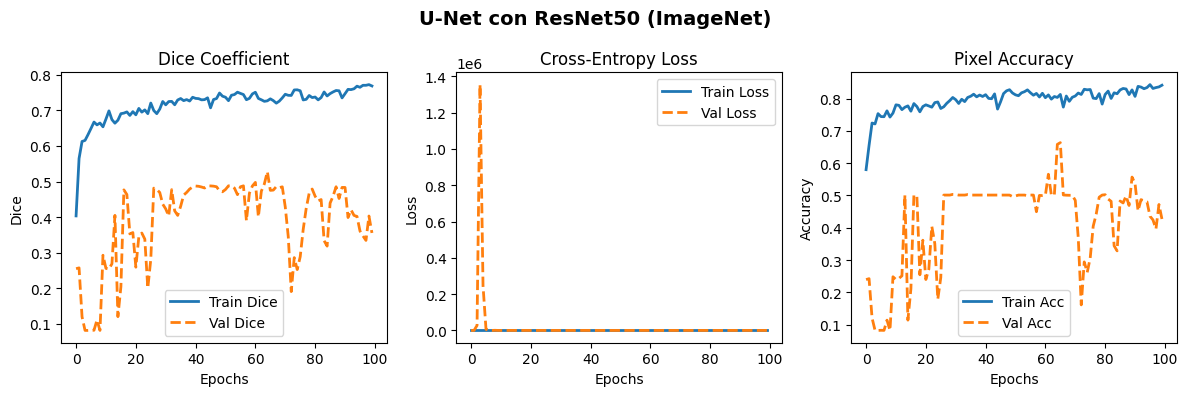

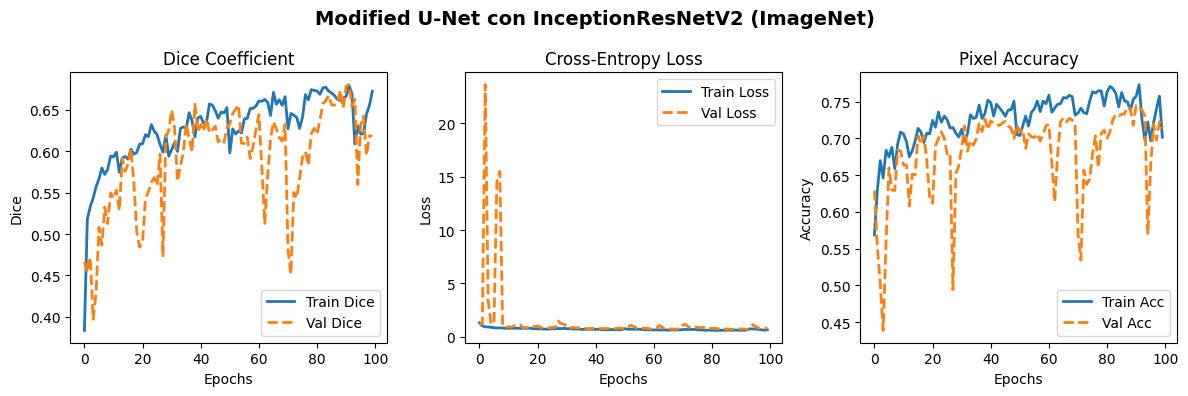

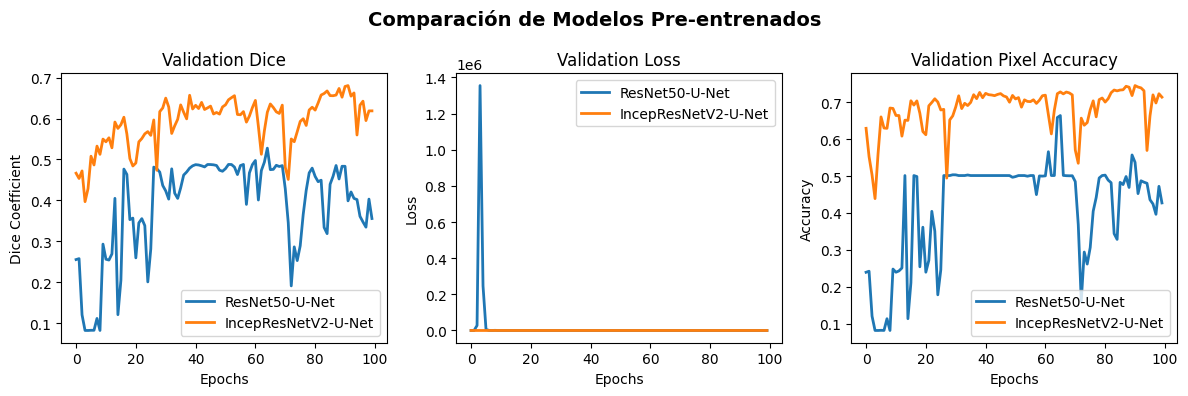

In [ ]:
# Curvas individuales
plot_history_single(hist_base, "U-Net con ResNet50 (ImageNet)")
plot_history_single(hist_mod,  "Modified U-Net con InceptionResNetV2 (ImageNet)")

# Comparación directa
plot_compare_histories(hist_base, hist_mod)


# Visualización

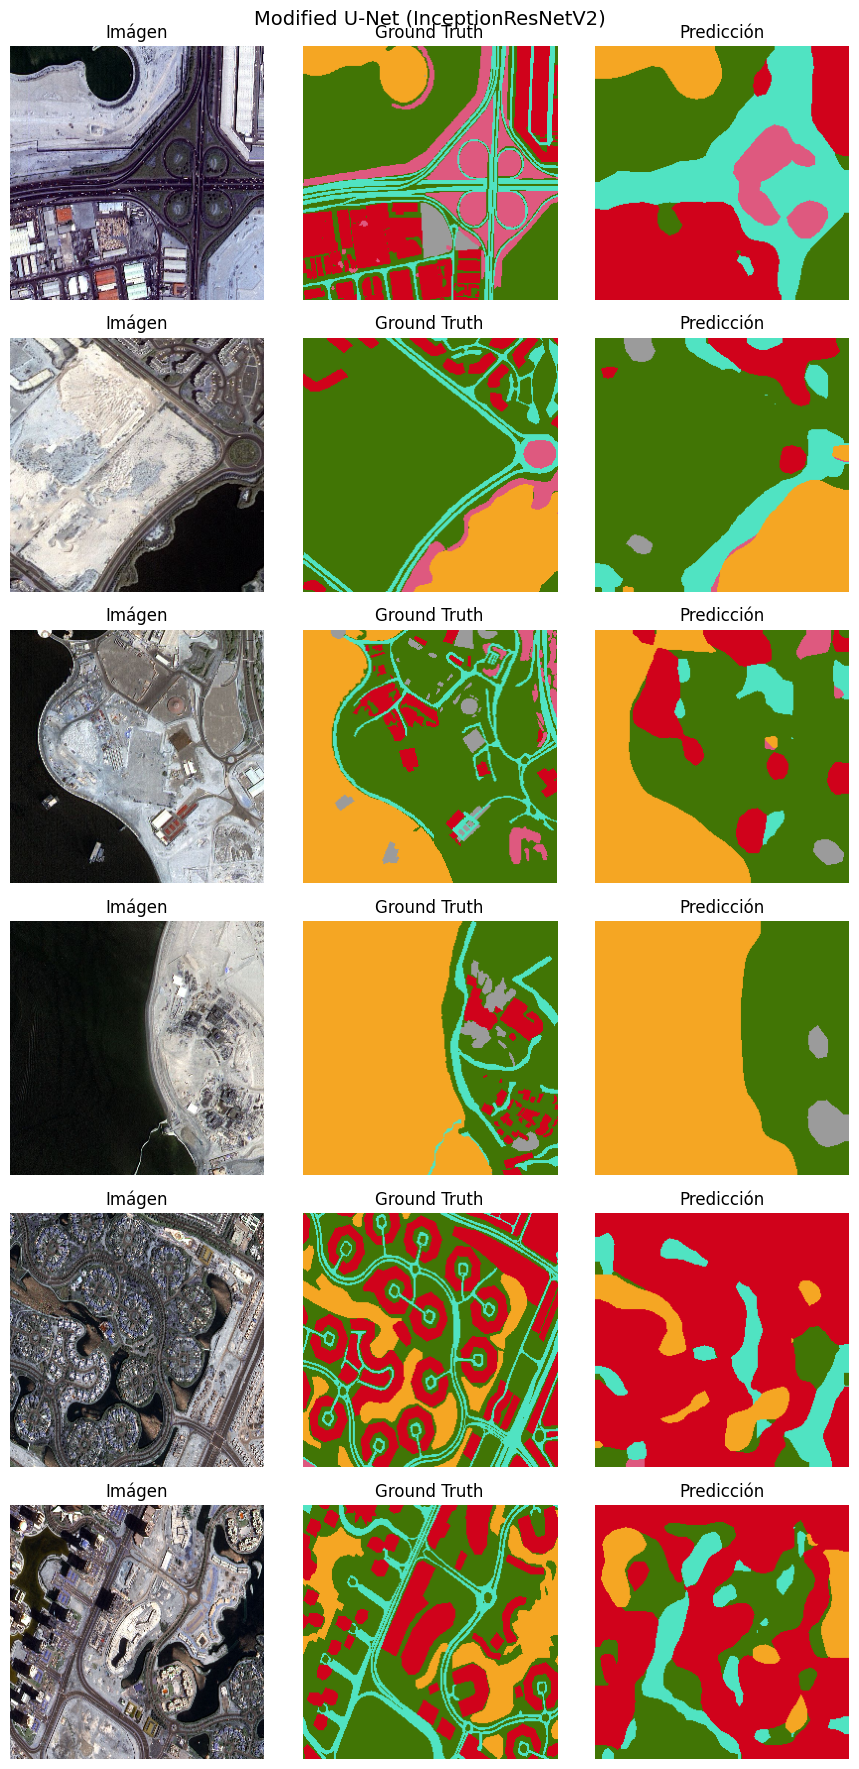

In [ ]:
ID2COLOR = np.array(PALETTE, dtype=np.uint8)

def quick_viz(model, dataset, N=6, title="Predicciones"):
    xb, yb = next(iter(dataset))
    pr = model.predict(xb, verbose=0)
    gt_idx = np.argmax(yb.numpy(), axis=-1)
    pr_idx = np.argmax(pr, axis=-1)

    N = min(N, xb.shape[0])
    plt.figure(figsize=(9, 3*N))
    for i in range(N):
        img = (xb[i].numpy()*255).astype(np.uint8)
        gt  = ID2COLOR[gt_idx[i]]
        pred= ID2COLOR[pr_idx[i]]

        r = i*3
        plt.subplot(N,3,r+1); plt.imshow(img); plt.axis("off"); plt.title("Imágen")
        plt.subplot(N,3,r+2); plt.imshow(gt);  plt.axis("off"); plt.title("Ground Truth")
        plt.subplot(N,3,r+3); plt.imshow(pred);plt.axis("off"); plt.title("Predicción")
    plt.suptitle(title, fontsize=14)
    plt.tight_layout(); plt.show()

quick_viz(unet_incepres, val_ds, N=6, title="Modified U-Net (InceptionResNetV2)")

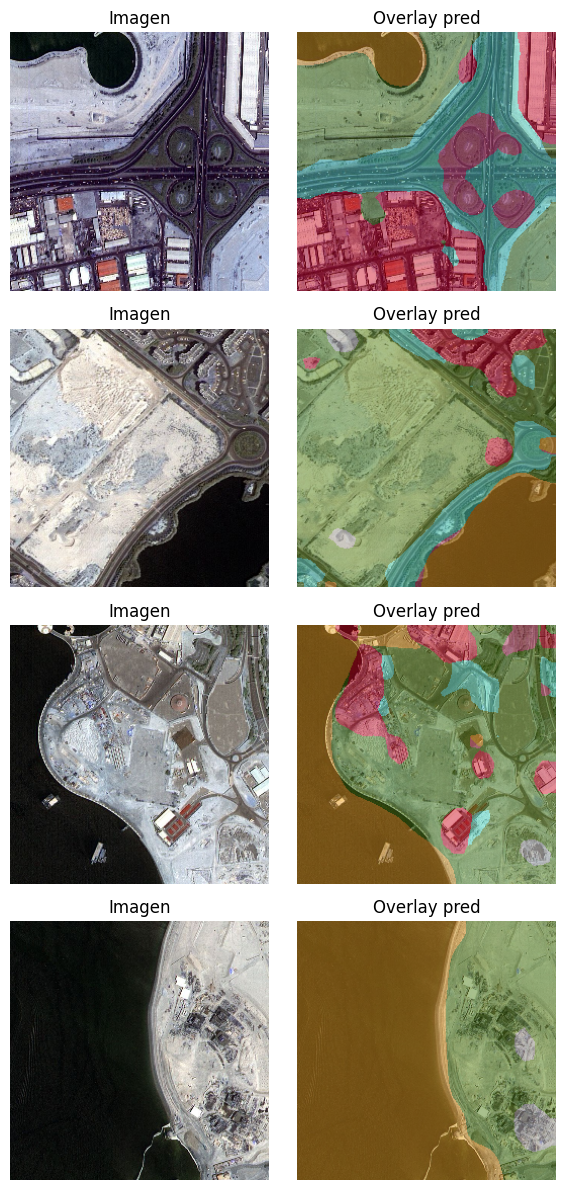

In [ ]:
def quick_overlay(model, dataset, N=6, alpha=0.45):
    xb, yb = next(iter(dataset))
    pr = model.predict(xb, verbose=0)
    pr_idx = np.argmax(pr, axis=-1)
    plt.figure(figsize=(6, 3*N))
    for i in range(min(N, xb.shape[0])):
        img = (xb[i].numpy()*255).astype(np.uint8)
        pred= ID2COLOR[pr_idx[i]]
        over = ((1-alpha)*img + alpha*pred).astype(np.uint8)
        plt.subplot(N,2,2*i+1); plt.imshow(img);  plt.axis("off"); plt.title("Imagen")
        plt.subplot(N,2,2*i+2); plt.imshow(over); plt.axis("off"); plt.title("Overlay pred")
    plt.tight_layout(); plt.show()

quick_overlay(unet_incepres, val_ds, N=4)